In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
cereal_df = pd.read_csv("C:/Users/admin/Desktop/Agri-Hotri_Price/Data/Cereal_Final.csv")
veg_df = pd.read_csv("C:/Users/admin/Desktop/Agri-Hotri_Price/Data/Vegetable_Final.csv")

In [21]:
columns_c = ['date', 'rolling_median_7','season', 'msp_commodity', 'Year', 'State', 'Month_Num','Month']
columns_v = ['Year', 'State', 'Month_Num','Month']
cereal_df = cereal_df.drop(columns=columns_c)
veg_df = veg_df.drop(columns=columns_v)

In [24]:
cereal_df.columns

Index(['Date', 'modal_price', 'min_price', 'max_price', 'Change (₹)',
       'arrivals', 'Change (Tonne)', 'commodity', 'zero_arrival_flag', 'msp',
       'temperature', 'rainfall', 'solar_radiation', 'wind_speed',
       'rainfall_30d', 'rainfall_60d', 'temp_14d_avg', 'market_closed_flag',
       'price_to_msp_ratio', 'below_msp_flag', 'arrivals_lag_7',
       'arrivals_pct_change_7', 'arrival_rolling_14', 'supply_stress_index',
       'Petrol_price', 'Diesel_price', 'diesel_lag_7', 'diesel_lag_30',
       'petrol_lag_7', 'petrol_lag_30', 'diesel_pct_change_30'],
      dtype='object')

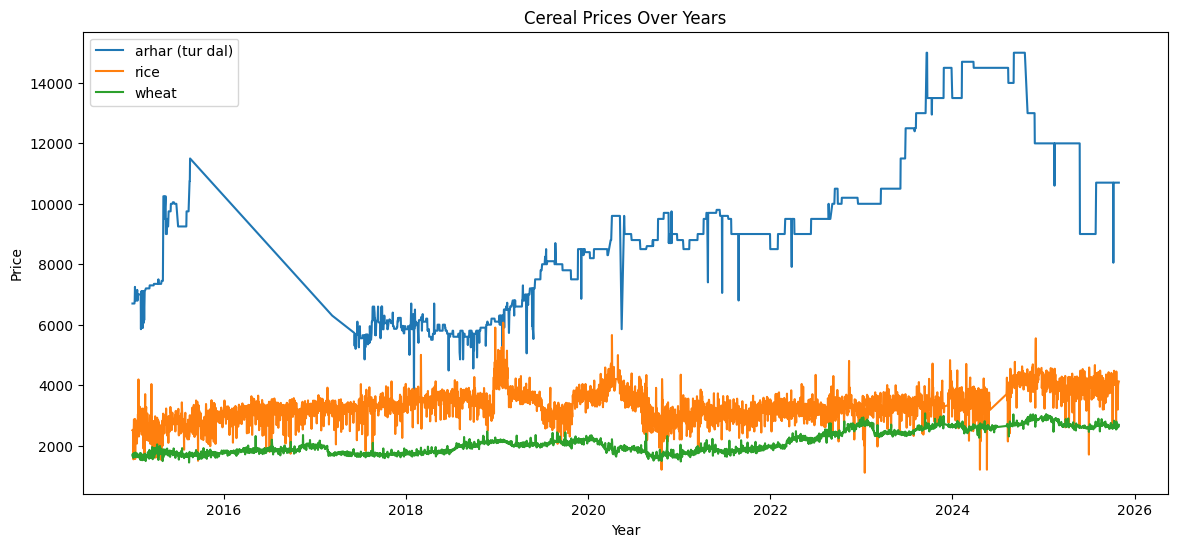

In [27]:
cereal_df["Date"] = pd.to_datetime(cereal_df["Date"])


plt.figure(figsize=(14,6))

for product in cereal_df["commodity"].unique():
    temp = cereal_df[cereal_df["commodity"] == product]
    plt.plot(temp["Date"], temp["modal_price"], label=product)



plt.title("Cereal Prices Over Years")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

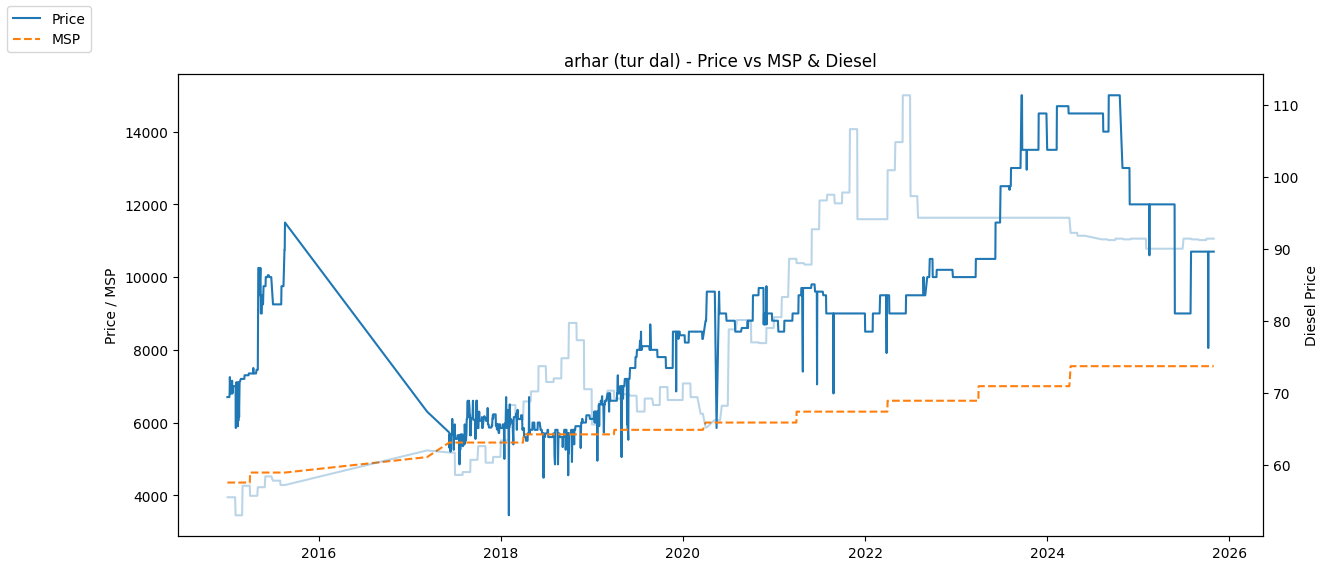

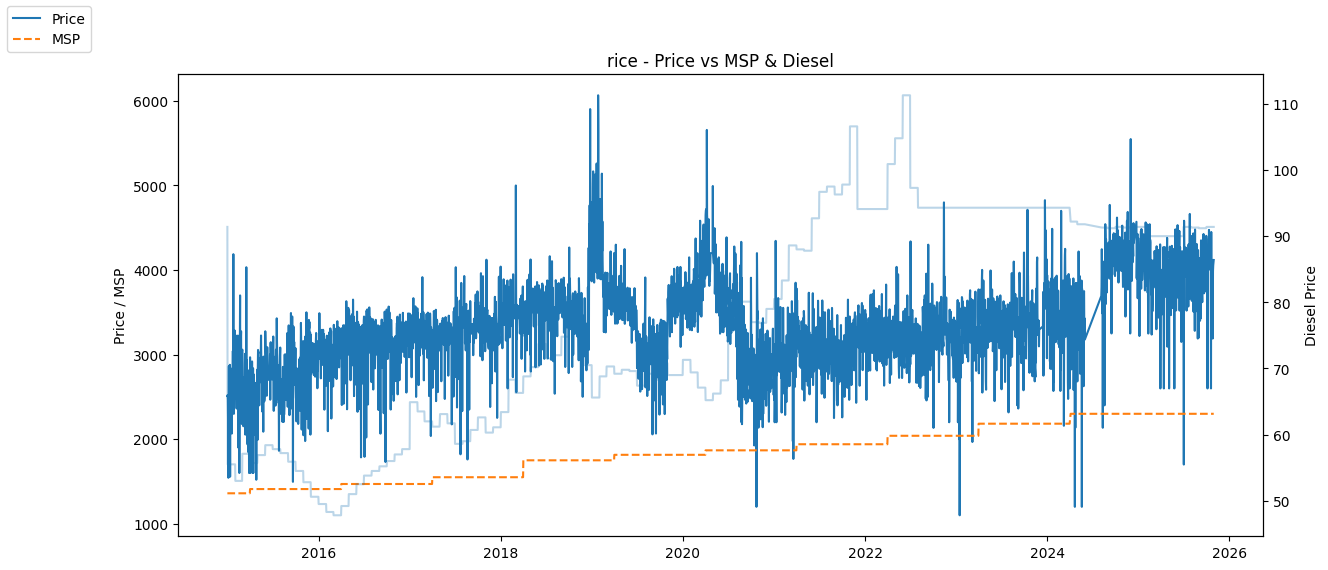

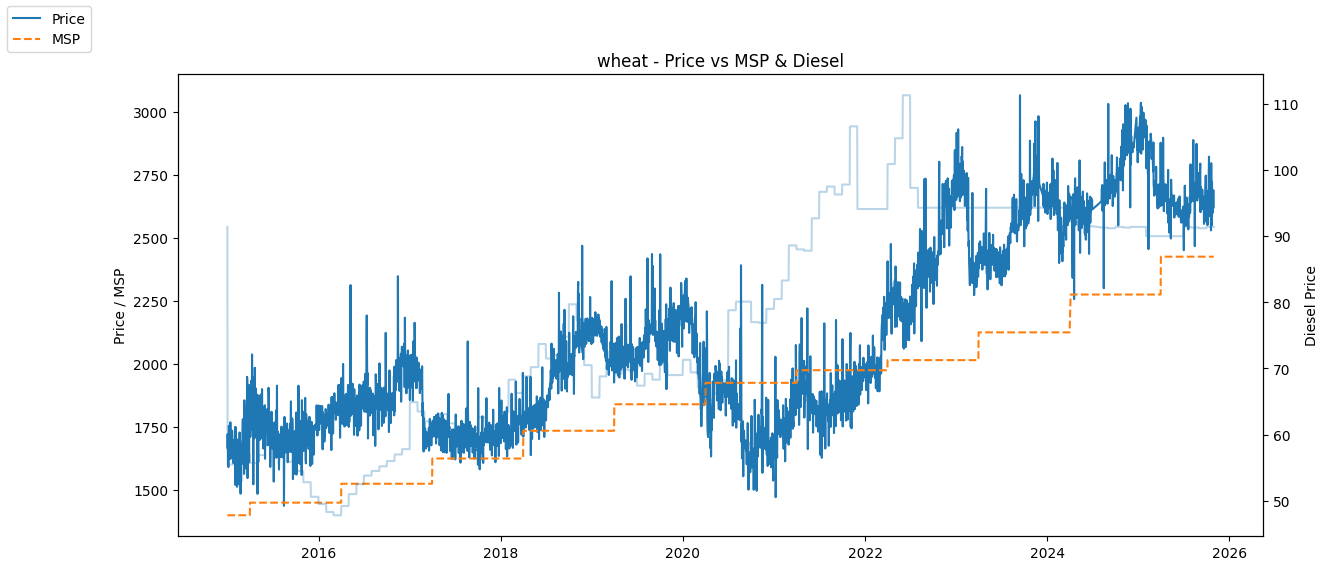

In [29]:
for product in cereal_df["commodity"].unique():
    temp = cereal_df[cereal_df["commodity"] == product]

    fig, ax1 = plt.subplots(figsize=(14,6))

    ax1.plot(temp["Date"], temp["modal_price"], label="Price")
    ax1.plot(temp["Date"], temp["msp"], linestyle="--", label="MSP")
    ax1.set_ylabel("Price / MSP")

    ax2 = ax1.twinx()
    ax2.plot(temp["Date"], temp["Diesel_price"], alpha=0.3)
    ax2.set_ylabel("Diesel Price")

    plt.title(f"{product} - Price vs MSP & Diesel")
    fig.legend(loc="upper left")
    plt.show()

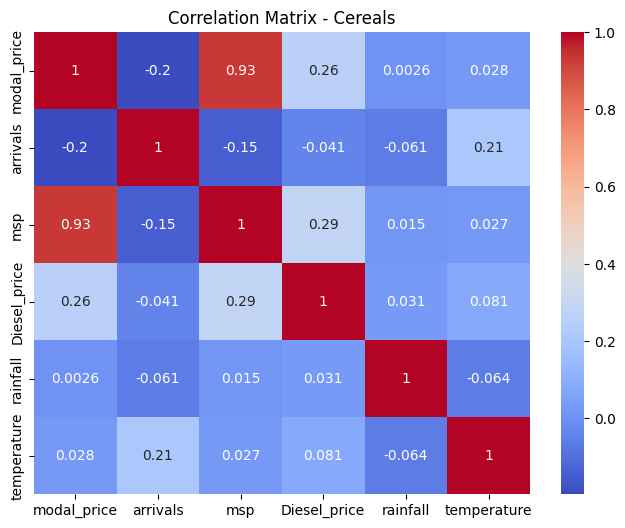

In [31]:
corr_cols = ["modal_price", "arrivals", "msp", "Diesel_price", "rainfall", "temperature"]

plt.figure(figsize=(8,6))
sns.heatmap(cereal_df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Cereals")
plt.show()

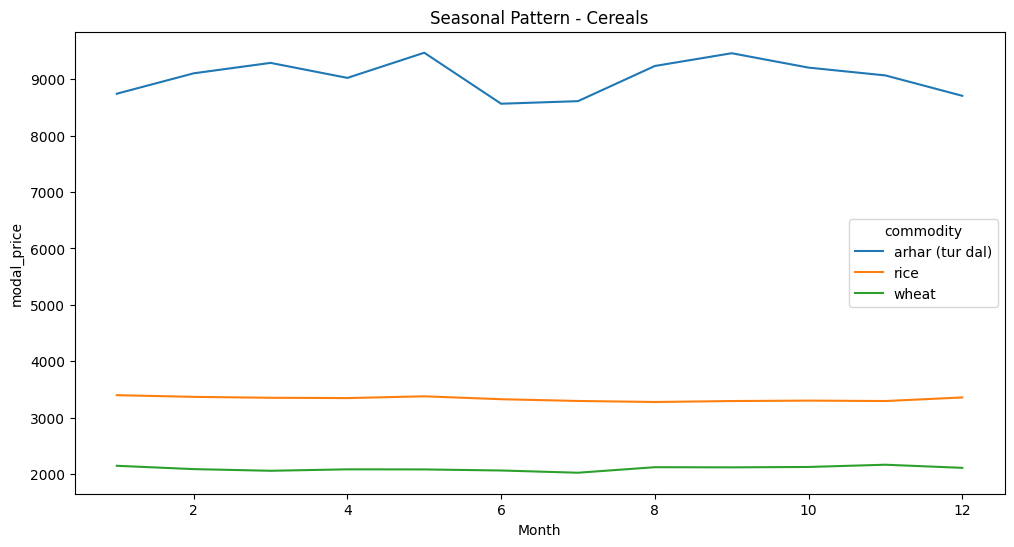

In [33]:
cereal_df["Month"] = cereal_df["Date"].dt.month

monthly_avg = cereal_df.groupby(["Month","commodity"])["modal_price"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_avg, x="Month", y="modal_price", hue="commodity")
plt.title("Seasonal Pattern - Cereals")
plt.show()

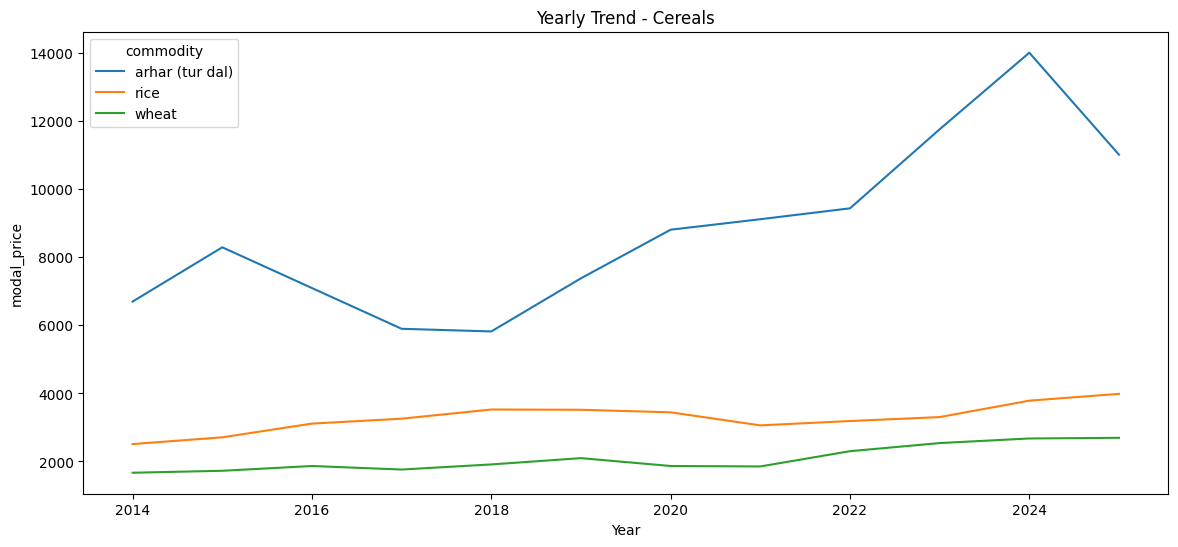

In [50]:
cereal_df["Year"] = cereal_df["Date"].dt.year
yearly_avg = cereal_df.groupby(["Year","commodity"])["modal_price"].mean().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=yearly_avg, x="Year", y="modal_price", hue="commodity")
plt.title("Yearly Trend - Cereals")
plt.show()

In [35]:
veg_df["date"] = pd.to_datetime(veg_df["date"])
veg_df.columns

Index(['modal_price', 'Min Price (₹)', 'Max Price (₹)', 'Change (₹)',
       'arrivals', 'Change (Tonne)', 'commodity', 'date', 'temperature',
       'rainfall', 'solar_radiation', 'wind_speed', 'rainfall_7d',
       'rainfall_15d', 'temp_7d_avg', 'Petrol_price', 'Diesel_price',
       'diesel_lag_7', 'diesel_lag_30', 'petrol_lag_7', 'petrol_lag_30',
       'diesel_pct_change_30', 'market_closed_flag', 'price_lag_1',
       'price_lag_3', 'price_lag_7', 'price_pct_change_3', 'arrival_lag_3',
       'arrival_shock', 'arrival_rolling_7', 'supply_tightness',
       'price_volatility_7'],
      dtype='object')

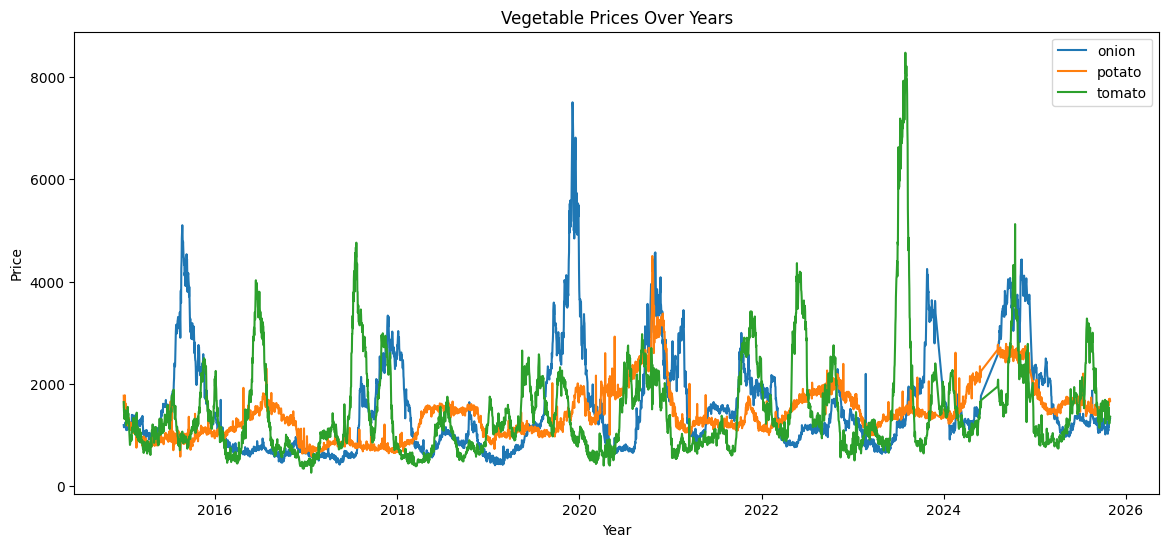

In [36]:
plt.figure(figsize=(14,6))

for product in veg_df["commodity"].unique():
    temp = veg_df[veg_df["commodity"] == product]
    plt.plot(temp["date"], temp["modal_price"], label=product)

plt.title("Vegetable Prices Over Years")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

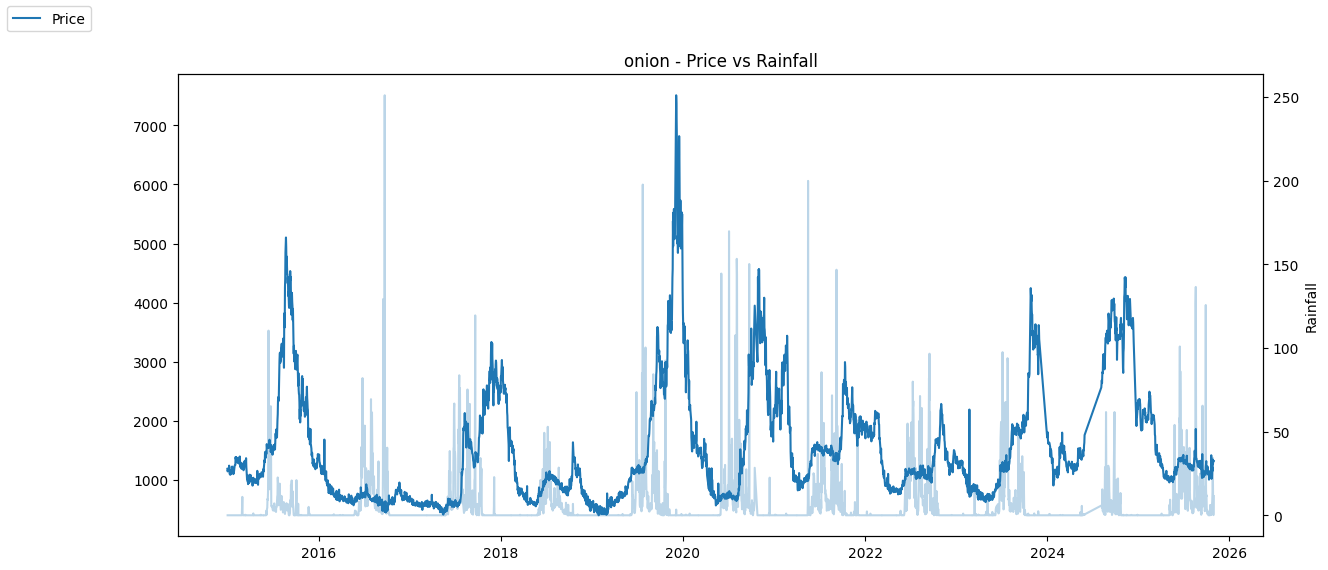

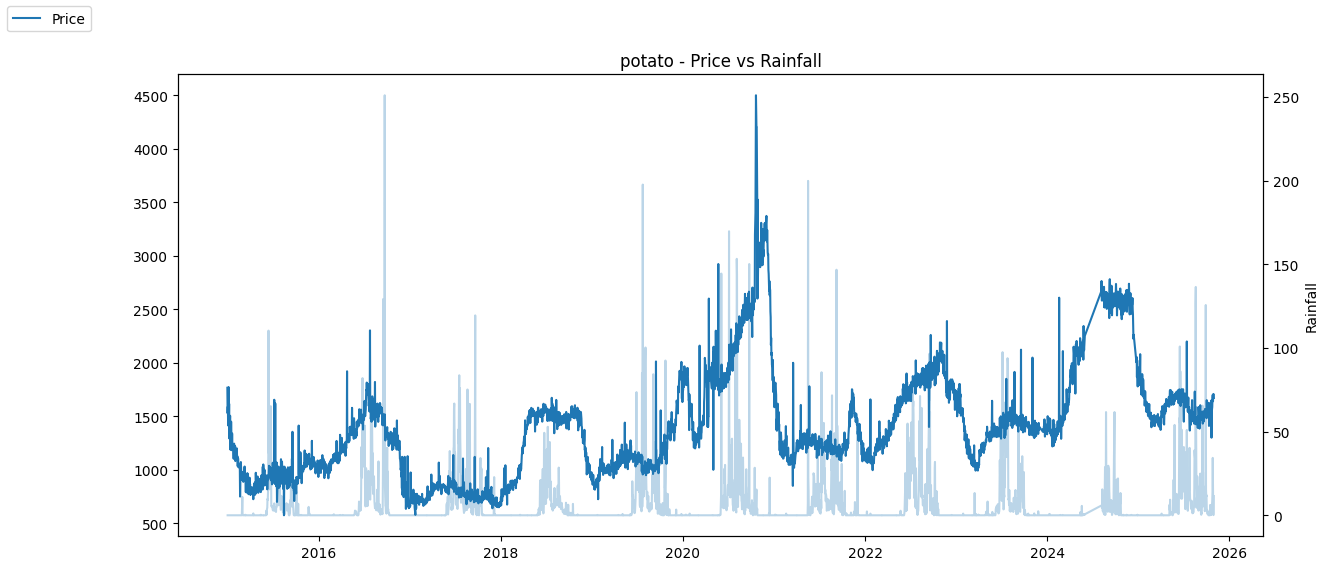

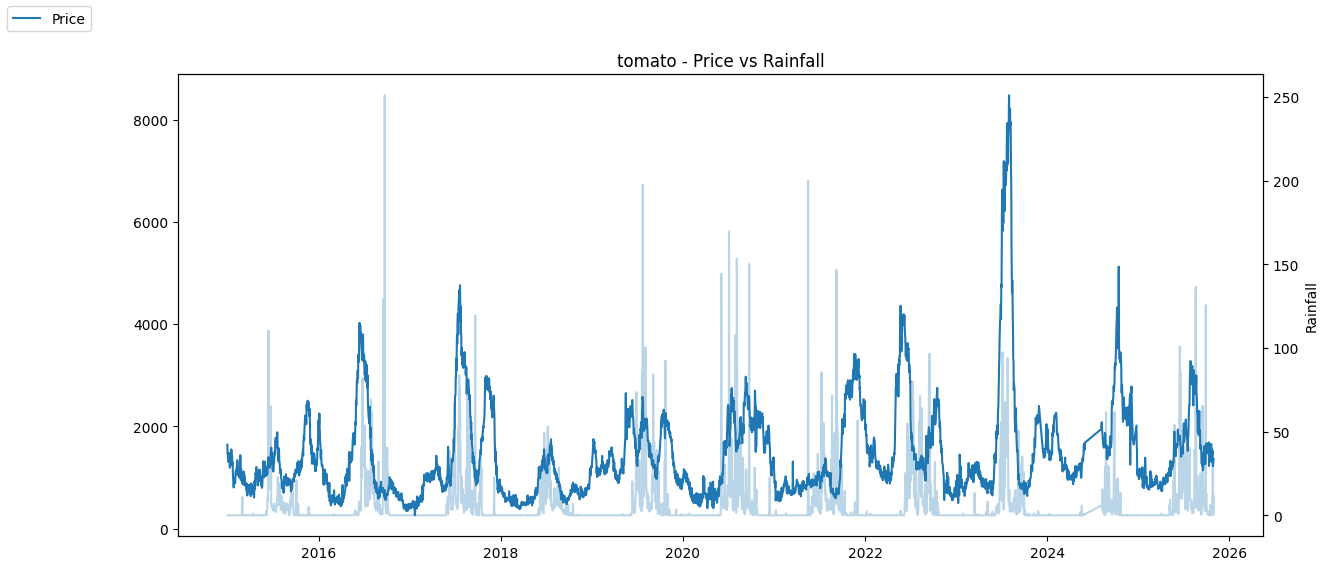

In [37]:
for product in veg_df["commodity"].unique():
    temp = veg_df[veg_df["commodity"] == product]

    fig, ax1 = plt.subplots(figsize=(14,6))

    ax1.plot(temp["date"], temp["modal_price"], label="Price")

    ax2 = ax1.twinx()
    ax2.plot(temp["date"], temp["rainfall"], alpha=0.3)
    ax2.set_ylabel("Rainfall")

    plt.title(f"{product} - Price vs Rainfall")
    fig.legend(loc="upper left")
    plt.show()

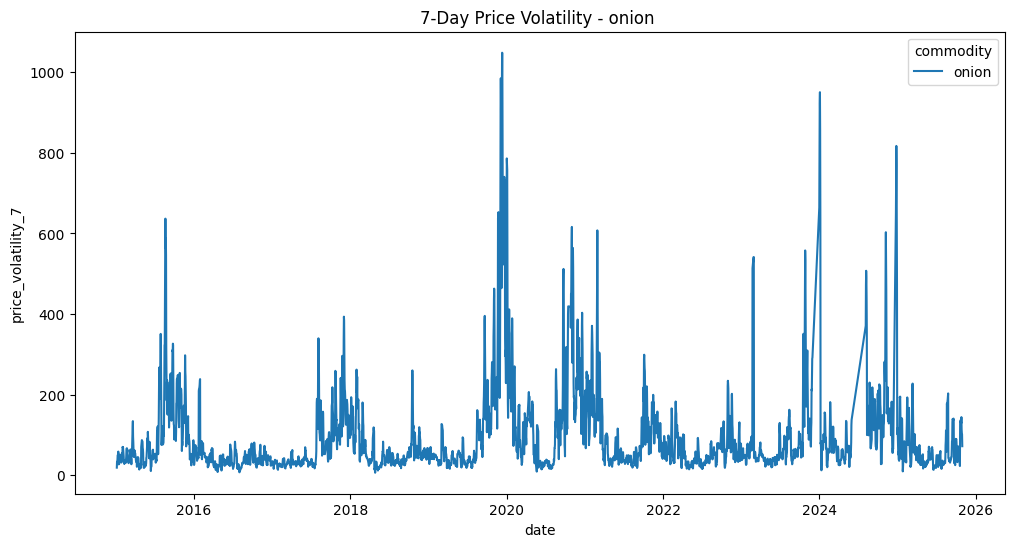

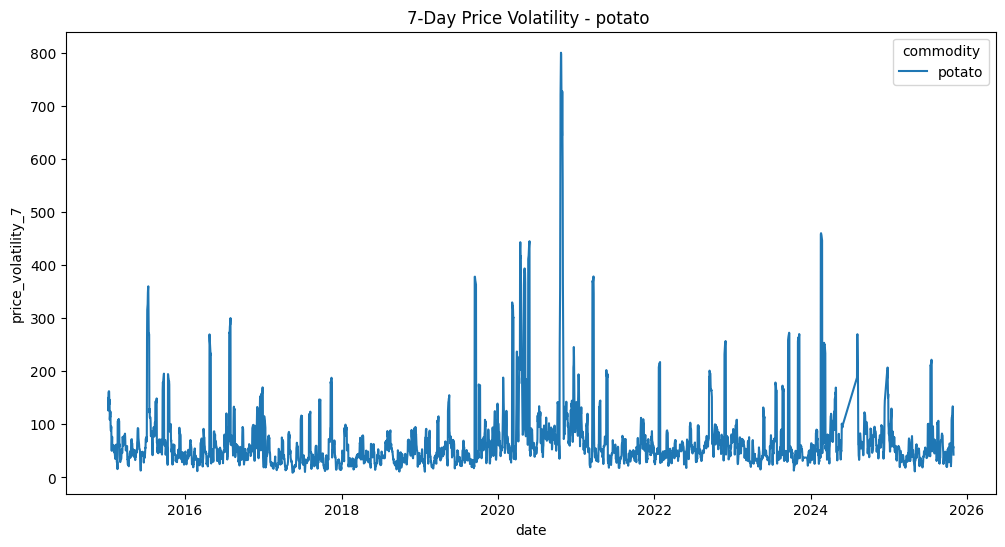

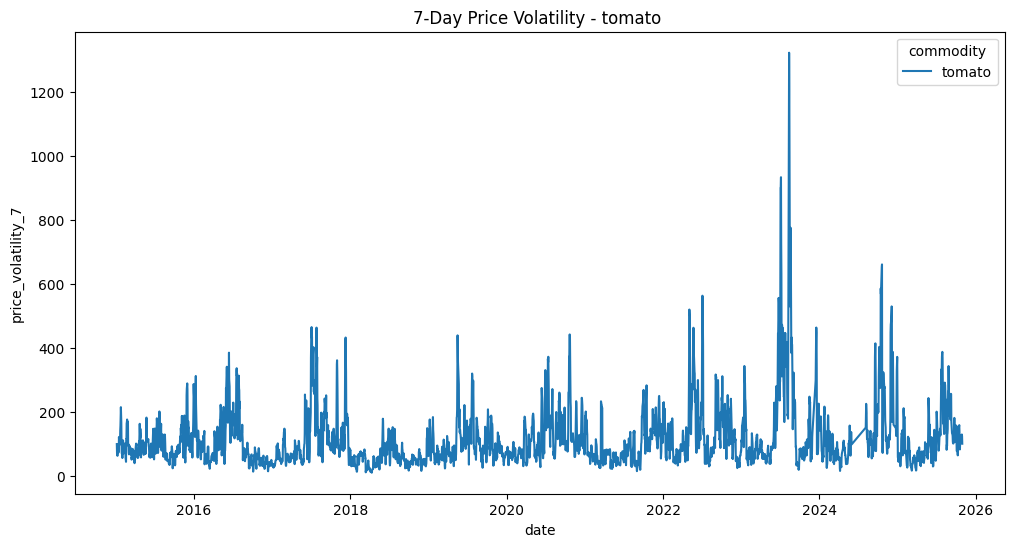

In [47]:
for product in veg_df["commodity"].unique():
    temp = veg_df[veg_df["commodity"] == product]
    plt.figure(figsize=(12,6))
    sns.lineplot(data=temp, x="date", y="price_volatility_7", hue="commodity")
    plt.title(f"7-Day Price Volatility - {product} ")
    plt.show()

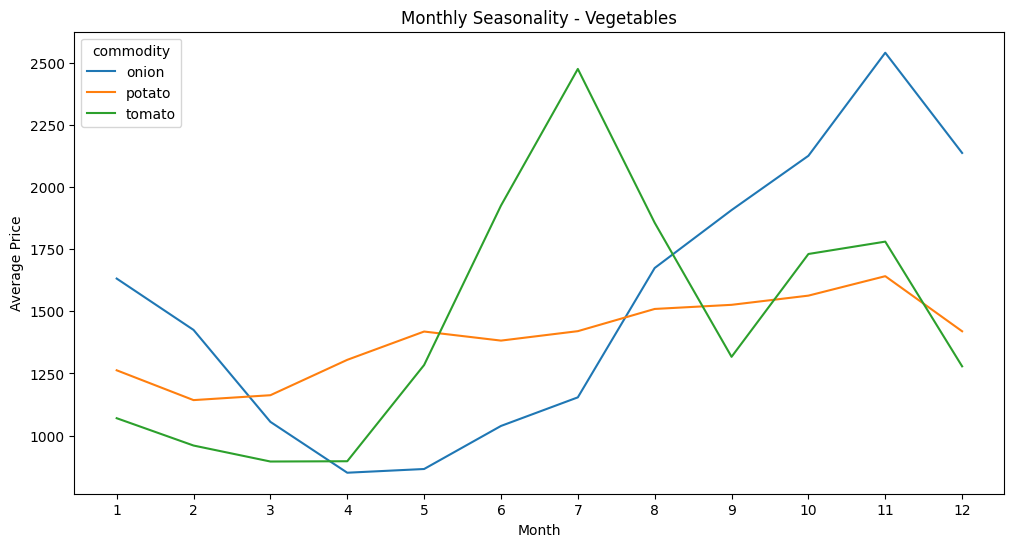

In [51]:
veg_df["Month"] = veg_df["date"].dt.month

monthly_avg = (
    veg_df
    .groupby(["commodity", "Month"])["modal_price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_avg, x="Month", y="modal_price", hue="commodity")

plt.title("Monthly Seasonality - Vegetables")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(range(1,13))
plt.show()

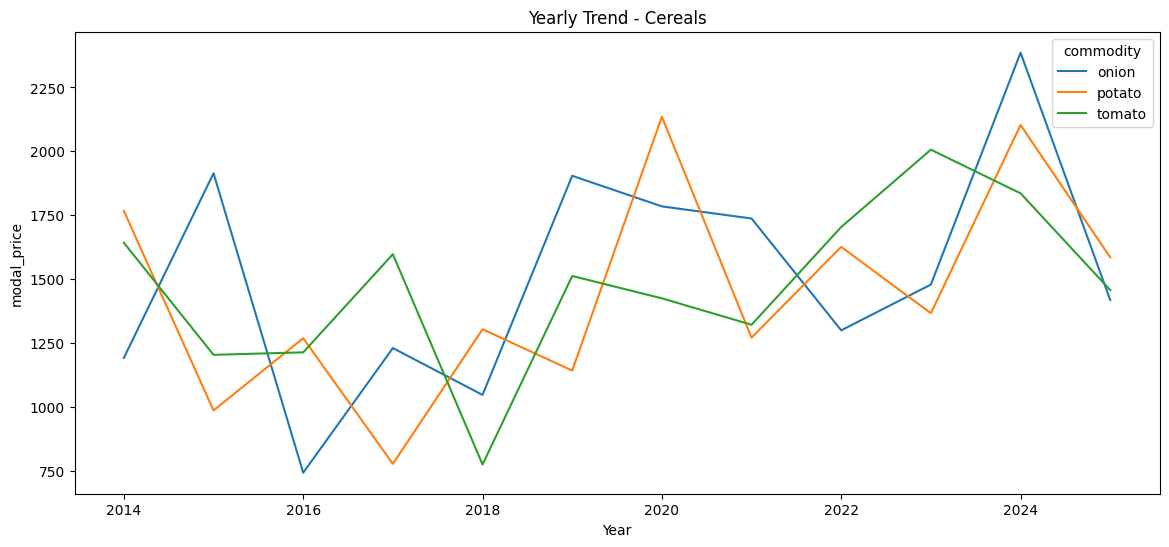

In [54]:
veg_df["Year"] = veg_df["date"].dt.year
yearly_avg = veg_df.groupby(["Year","commodity"])["modal_price"].mean().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=yearly_avg, x="Year", y="modal_price", hue="commodity")
plt.title("Yearly Trend - Cereals")
plt.show()